<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_2_Confusion_Matrix_Basic_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Part 2
## The Confusion Matrix and Metrics

Author: Brad Sheese

---

## Introduction: Moving Beyond Accuracy

In the previous notebook, we saw that our Credit Default dataset is imbalanced (~70% good, ~30% bad). We learned that accuracy can be a trap—a model that does nothing but guess "Good" for everyone is 70% accurate, but it fails to catch any defaults.

In this notebook, we dive into the tool that data scientists use to see the "full picture": the confusion matrix. We will learn how to dissect a model's successes and failures using four fundamental metrics: accuracy, precision, recall, and f1-score.

### Learning Objectives
By the end of this notebook, you will be able to:
1. Build and interpret a confusion matrix.
2. Identify type I (false alarm) vs. type II (missed case) errors.
3. Calculate and interpret precision and recall in a business context.
4. Use the f1-score to balance the trade-off between different types of errors.

## Section 1: Setup and Baseline Model

We'll reload the Credit Default data and retrain our XGBoost model using the `scale_pos_weight` parameter we introduced in Part 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

# Load and prepare data
data = fetch_openml(name='credit-g', version=1, as_frame=True)
df = data.frame

y = (df['class'] == 'bad').astype(int)
X = df.drop(columns=['class'])
X_encoded = pd.get_dummies(X, drop_first=True)

# Clean column names for XGBoost compatibility
import re
X_encoded.columns = [re.sub(r"[<>[\]]", "_", col) for col in X_encoded.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Train XGBoost model
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Setup complete. Model trained!")


Setup complete. Model trained!


## Section 2: The Confusion Matrix (The Error Map)

The confusion matrix is a table that maps the model's predictions against the actual outcomes. It allows us to see exactly where the "confusion" is happening.

### Terminology:
- True Positives (TP): We predicted Default, and they did Default. (Success!)
- True Negatives (TN): We predicted Good, and they were Good. (Success!)
- False Positives (FP): We predicted Default, but they were Good. (False alarm / Type I error).
- False Negatives (FN): We predicted Good, but they actually Defaulted. (Missed case / Type II error).

--- Confusion Matrix Breakdown ---
True Negatives  (TN) — Correctly Identified Good: 166
True Positives  (TP) — Correctly Identified Bad:  53
False Positives (FP) — False Alarms / Type I:     44
False Negatives (FN) — Missed Defaults / Type II: 37


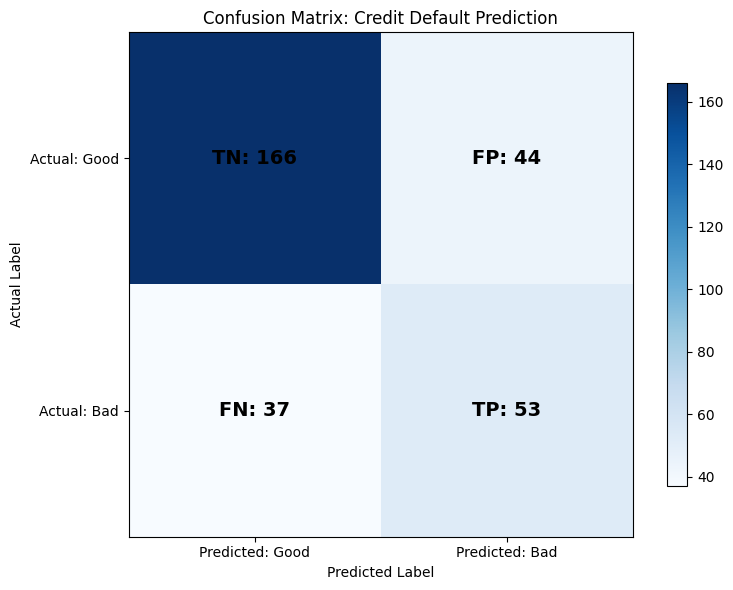

In [2]:
# Generate the matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"--- Confusion Matrix Breakdown ---")
print(f"True Negatives  (TN) — Correctly Identified Good: {tn}")
print(f"True Positives  (TP) — Correctly Identified Bad:  {tp}")
print(f"False Positives (FP) — False Alarms / Type I:     {fp}")
print(f"False Negatives (FN) — Missed Defaults / Type II: {fn}")

# Visualize with labeled cells
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Good', 'Predicted: Bad'])
ax.set_yticklabels(['Actual: Good', 'Actual: Bad'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix: Credit Default Prediction')

# Add labels with both count and terminology
labels = [
    [f'TN: {tn}', f'FP: {fp}'],
    [f'FN: {fn}', f'TP: {tp}']
]
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i][j], ha='center', va='center', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### Interpreting the Results

Our model made 44 false alarms and 37 missed defaults.

In business terms:
- 44 good customers were wrongly denied loans. These are customers who would have paid back their loan, but the model flagged them as risky. The bank loses their interest income and potentially damages customer relationships.
- 37 defaulters were wrongly approved. These are customers who will not pay back their loan. The bank loses the principal amount lent.

Which error costs the bank more? That depends on your risk tolerance. A conservative bank might prefer false alarms (deny some good customers) over missed defaults (approve risky ones). A growth-oriented bank might accept more defaults to capture more good customers.

## Section 3: Precision and Recall (The Trade-Off)

Recall from Part 1 that our model achieved an accuracy above the 70% naive baseline. But accuracy alone doesn't tell us *which* predictions are correct. To get a better sense of how the model handles the "Bad" class, we use precision and recall.

### Precision: How reliable are our positive hits?
When the model flags someone as a default risk, how often is it right?
$$precision = \frac{TP}{TP + FP}$$
High precision means you have very few false alarms.

### Recall: How many actual cases did we catch?
Of all the people who actually defaulted, what percentage did we catch?
$$recall = \frac{TP}{TP + FN}$$
High recall means you have very few missed cases.

### Why the F1-Score Matters
Imagine a model with precision = 100% but recall = 1%. It flags exactly one person as a defaulter and is right — perfect precision! But it missed 99% of actual defaulters. The arithmetic mean would be ~50%, making the model look decent. The F1-score is ~2%, correctly revealing the model is nearly useless. The harmonic mean punishes extreme imbalances between precision and recall.

$$F1 = 2 \times \frac{precision \times recall}{precision + recall}$$

In [3]:
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {prec*100:.1f}% (Reliability of Default predictions)")
print(f"Recall:    {rec*100:.1f}% (Percentage of actual Defaults caught)")
print(f"F1-Score:  {f1*100:.1f}% (Balance between precision and recall)")

Precision: 54.6% (Reliability of Default predictions)
Recall:    58.9% (Percentage of actual Defaults caught)
F1-Score:  56.7% (Balance between precision and recall)


### The Full Classification Report

Scikit-learn provides `classification_report`, which shows precision, recall, and f1-score for each class along with the number of samples (support).

In [4]:
print(classification_report(y_test, y_pred, target_names=['Good (0)', 'Bad (1)']))

              precision    recall  f1-score   support

    Good (0)       0.82      0.79      0.80       210
     Bad (1)       0.55      0.59      0.57        90

    accuracy                           0.73       300
   macro avg       0.68      0.69      0.69       300
weighted avg       0.74      0.73      0.73       300



### Reading the Report

- Support is the number of actual instances of each class in the test set. Notice there are far more 'Good' samples than 'Bad' — this is the class imbalance we discussed.
- Macro avg treats both classes equally, regardless of how many samples each has. This tells you how the model performs on the minority class just as much as the majority class.
- Weighted avg weights each class by its support. This is closer to accuracy but still accounts for per-class performance.

Which average matters depends on your goals. If catching defaults is your priority, look at the 'Bad (1)' row directly. If you need a single number that treats both classes fairly, use macro average.

## Section 4: The Threshold Trade-Off (Preview)

Remember the probability distributions from Part 1? The model assigns each applicant a probability of default. By default, we split at 0.5 — but what if we moved that line?

- If we move the threshold higher, we become more conservative. Precision goes up (we only flag people we are certain about), but recall goes down (we miss more people).
- If we move the threshold lower, we become more sensitive. Recall goes up (we catch almost everyone), but precision goes down (we have many false alarms).

In the next notebook, we'll explore this trade-off systematically using ROC curves, AUC, and Youden's J statistic — tools that let us evaluate a model's performance across *all* possible thresholds simultaneously.

### Your Turn

1. Given this confusion matrix: `[[180, 20], [30, 70]]`, calculate precision, recall, and F1 by hand. Then verify your answers using the formulas above.
2. If a bank's policy is "never deny a good customer," which metric should they maximize: precision or recall? Why?
3. Look at the classification report above. The 'Good (0)' class has a higher recall than the 'Bad (1)' class. What does this tell you about the model's behavior?

## Conclusion

We've moved from simple "guessing" to a nuanced evaluation of our model. Key takeaways:

1. Accuracy hides errors in imbalanced data. The confusion matrix reveals exactly where the model fails.
2. Precision measures reliability — when the model says "default," how often is it right?
3. Recall measures sensitivity — of all actual defaulters, how many did we catch?
4. F1-score finds the middle ground — it punishes models that are great at one but terrible at the other.

In the next notebook, we'll look at ROC curves and AUC, which allow us to evaluate a model's performance across *all* possible thresholds simultaneously. We'll also learn Youden's J statistic — a systematic way to find the mathematically optimal threshold for your specific problem.